In [19]:
# Inisialisasi Direktori dan Konstanta Proyek
import os

DATASET_DIR = "dataset"
MODEL_DIR = "model"

os.makedirs(MODEL_DIR, exist_ok=True)

In [20]:
# Memuat Dataset Caption Gambar
import os
import pandas as pd

def load_captions():
    path = os.path.join(DATASET_DIR, "captions.xlsx")
    df = pd.read_excel(path)
    df.columns = df.columns.str.lower()
    df["caption"] = df["caption"].astype(str)
    return df


In [21]:
# Preprocessing Teks Caption
def clean_caption(text):
    text = text.lower().strip()
    text = ''.join(c for c in text if c.isalnum() or c.isspace())
    return f"startseq {text} endseq"

In [22]:
# Pembersihan dan Persiapan Data Caption
df = load_captions()
df["cleaned"] = df["caption"].apply(clean_caption)

captions = df["cleaned"].tolist()
filenames = df["filename"].tolist()


In [23]:
# Fungsi Ekstraksi Fitur Gambar
import numpy as np
from PIL import Image
from tensorflow.keras.applications.inception_v3 import preprocess_input

def extract_feature(img_path, model):
    img = Image.open(img_path).convert("RGB")
    img = img.resize((299, 299))
    x = np.expand_dims(np.array(img), axis=0)
    x = preprocess_input(x)
    feat = model.predict(x, verbose=0)
    return feat.flatten()


In [24]:
# Inisialisasi Model CNN (InceptionV3) sebagai Encoder
from tensorflow.keras.applications.inception_v3 import InceptionV3

extractor = InceptionV3(
    include_top=False,
    weights="imagenet",
    pooling="avg"
)


In [25]:
# Ekstraksi Fitur Gambar dari Dataset
import os
import numpy as np

features = []
clean_caps = []

img_dir = os.path.join(DATASET_DIR, "images")

for i, fname in enumerate(filenames):
    img_path = os.path.join(img_dir, fname)

    if not os.path.exists(img_path):
        print("Missing:", img_path)
        continue

    feat = extract_feature(img_path, extractor)
    features.append(feat)
    clean_caps.append(captions[i])

features = np.array(features)


In [26]:
# Tokenisasi Caption dan Pembuatan Vocabulary
import pickle
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer()
tokenizer.fit_on_texts(clean_caps)

with open(os.path.join(MODEL_DIR, "tokenizer.pkl"), "wb") as f:
    pickle.dump(tokenizer, f)

vocab_size = len(tokenizer.word_index) + 1
max_length = max(len(c.split()) for c in clean_caps)

with open(os.path.join(MODEL_DIR, "max_length.pkl"), "wb") as f:
    pickle.dump(max_length, f)

print("Vocab size:", vocab_size)
print("Max length:", max_length)


Vocab size: 662
Max length: 23


In [27]:
# Pembuatan Data Training Berbasis Sequence
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences

X1, X2, y = [], [], []

for i, cap in enumerate(clean_caps):
    seq = tokenizer.texts_to_sequences([cap])[0]

    for j in range(1, len(seq)):
        in_seq, out = seq[:j], seq[j]

        in_seq = pad_sequences([in_seq], maxlen=max_length)[0]
        out = tf.keras.utils.to_categorical(out, num_classes=vocab_size)

        X1.append(features[i])
        X2.append(in_seq)
        y.append(out)

X1 = np.array(X1)
X2 = np.array(X2)
y = np.array(y)

print(X1.shape, X2.shape, y.shape)


(3293, 2048) (3293, 23) (3293, 662)


In [ ]:
# Perancangan Arsitektur Model Image Captioning (Encoder–Decoder)
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense, Dropout, add
from tensorflow.keras.models import Model

def define_model(vocab_size, max_len):
    inputs1 = Input(shape=(2048,))
    fe1 = Dropout(0.5)(inputs1)
    fe2 = Dense(128, activation="relu")(fe1)

    inputs2 = Input(shape=(max_len,))
    se1 = Embedding(vocab_size,128, mask_zero=True)(inputs2)
    se2 = Dropout(0.3)(se1)
    se3 = LSTM(128)(se2)

    decoder = add([fe2, se3])
    decoder = Dense(128, activation="relu")(decoder)
    outputs = Dense(vocab_size, activation="softmax")(decoder)

    model = Model([inputs1, inputs2], outputs)
    model.compile(
        loss="categorical_crossentropy",
        optimizer="adam",
        metrics=["accuracy"]
    )
    return model


In [29]:
# Inisialisasi dan Ringkasan Model

model = define_model(vocab_size, max_length)
model.summary()


Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_6 (InputLayer)           [(None, 23)]         0           []                               
                                                                                                  
 input_5 (InputLayer)           [(None, 2048)]       0           []                               
                                                                                                  
 embedding_1 (Embedding)        (None, 23, 128)      84736       ['input_6[0][0]']                
                                                                                                  
 dropout_2 (Dropout)            (None, 2048)         0           ['input_5[0][0]']                
                                                                                            

In [30]:
# Proses Training Model Image Captioning
import tensorflow as tf

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    os.path.join(MODEL_DIR, "model_best.h5"),
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)


history = model.fit(
    [X1, X2], y,
    epochs=20,                 # boleh besar, tapi akan stop cepat
    batch_size=32,
    validation_split=0.2,
    callbacks=[checkpoint]
)



Epoch 1/20
83/83 [==============================] - ETA: 0s - loss: 5.6228 - accuracy: 0.0976
Epoch 1: val_loss improved from inf to 5.14543, saving model to model\model_best.h5
83/83 [==============================] - 17s 106ms/step - loss: 5.6228 - accuracy: 0.0976 - val_loss: 5.1454 - val_accuracy: 0.1335
Epoch 2/20
82/83 [============================>.] - ETA: 0s - loss: 4.9839 - accuracy: 0.1555
Epoch 2: val_loss improved from 5.14543 to 4.95587, saving model to model\model_best.h5
83/83 [==============================] - 5s 64ms/step - loss: 4.9834 - accuracy: 0.1553 - val_loss: 4.9559 - val_accuracy: 0.1517
Epoch 3/20
82/83 [============================>.] - ETA: 0s - loss: 4.6309 - accuracy: 0.1837
Epoch 3: val_loss improved from 4.95587 to 4.78772, saving model to model\model_best.h5
83/83 [==============================] - 6s 68ms/step - loss: 4.6279 - accuracy: 0.1841 - val_loss: 4.7877 - val_accuracy: 0.1912
Epoch 4/20
82/83 [============================>.] - ETA: 0s - loss

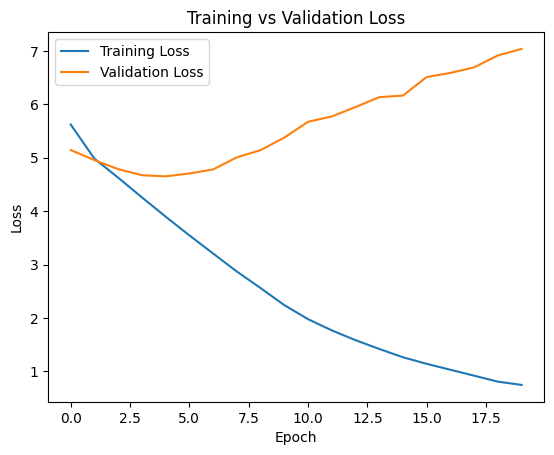

In [31]:
# Visualisasi Hasil Training (Loss dan Validation Loss)
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

In [32]:
# Penyimpanan Model dan Riwayat Training
import pickle

with open(os.path.join(MODEL_DIR, "history.pkl"), "wb") as f:
    pickle.dump(history.history, f)

model.save(os.path.join(MODEL_DIR, "model_final.h5"))

print("Training completed!")


Training completed!


In [33]:
# tambahkan sel untuk memprediksi citra pengujian citra dengan 5 citra yang berbeda
# tambahkan Data 

In [34]:
def generate_caption(model, tokenizer, photo_feature, max_length):
    in_text = 'startseq'
    for _ in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length)
        yhat = model.predict([np.array([photo_feature]), sequence], verbose=0)
        yhat = np.argmax(yhat)
        word = tokenizer.index_word.get(yhat, None)
        if word is None:
            break
        in_text += ' ' + word
        if word == 'endseq':
            break
    final_caption = in_text.replace('startseq', '').replace('endseq', '').strip()
    return final_caption

In [35]:
# ---------------- Prediksi Caption untuk 5 Gambar ----------------
test_images = [
    "test/test1.jpg",
    "test/test2.jfif",
    "test/test3.jpg",
    "test/test4.jpg",
    "test/test5.jpg"
]

for img_path in test_images:
    # Ekstrak fitur gambar
    photo_feature = extract_feature(img_path, extractor)
    
    # Generate caption
    caption = generate_caption(model, tokenizer, photo_feature, max_length)
    
    # Tampilkan hasil
    print(f"Gambar: {img_path}")
    print("Caption Prediksi:", caption)
    print("-" * 50)

Gambar: test/test1.jpg
Caption Prediksi: seorang pria berbaju merah memegang tentang sambil melihat ke luar masuk
--------------------------------------------------
Gambar: test/test2.jfif
Caption Prediksi: seorang pendaki berpakaian mendaki tebing di atas batu gurun
--------------------------------------------------
Gambar: test/test3.jpg
Caption Prediksi: seekor anjing sedang melompat melintasi salju
--------------------------------------------------
Gambar: test/test4.jpg
Caption Prediksi: seorang pria berdiri di puncak gunung dengan latar belakang pria
--------------------------------------------------
Gambar: test/test5.jpg
Caption Prediksi: seorang pria dan seorang anak berdiri di toko barang dari luar
--------------------------------------------------


In [36]:
# ---------------- Prediksi Caption ----------------
from nltk.translate.bleu_score import sentence_bleu
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

test_image_path = "test/test2.jfif"
reference_caption = "Seorang pria sedang memanjat tebing"  # caption asli / ground truth

# Ekstrak fitur gambar
photo_feature = extract_feature(test_image_path, extractor)
# Generate caption
candidate_caption = generate_caption(model, tokenizer, photo_feature, max_length)

print("Caption Prediksi:", candidate_caption)
print("Caption Referensi:", reference_caption)

# ---------------- Hitung BLEU ----------------
smooth_fn = SmoothingFunction().method1
bleu1 = sentence_bleu([reference_caption.split()], candidate_caption.split(), weights=(1,0,0,0), smoothing_function=smooth_fn)
bleu2 = sentence_bleu([reference_caption.split()], candidate_caption.split(), weights=(0.5,0.5,0,0), smoothing_function=smooth_fn)
bleu3 = sentence_bleu([reference_caption.split()], candidate_caption.split(), weights=(0.33,0.33,0.33,0), smoothing_function=smooth_fn)
bleu4 = sentence_bleu([reference_caption.split()], candidate_caption.split(), weights=(0.25,0.25,0.25,0.25), smoothing_function=smooth_fn)

print(f"BLEU-1: {bleu1:.4f}")
print(f"BLEU-2: {bleu2:.4f}")
print(f"BLEU-3: {bleu3:.4f}")
print(f"BLEU-4: {bleu4:.4f}")

Caption Prediksi: seorang pendaki berpakaian mendaki tebing di atas batu gurun
Caption Referensi: Seorang pria sedang memanjat tebing
BLEU-1: 0.1111
BLEU-2: 0.0373
BLEU-3: 0.0281
BLEU-4: 0.0240
